# 第 8 章 · TransE 与注意力代码实验

本页把“关系”和“注意力”都变成可计算过程。TransE 部分先训练国家到首都的关系向量；Attention 部分看一个词主要关注句子里的哪些词。

[章节网页](../ch8.html)

## 运行内容

- 训练国家-首都 TransE
- 计算 Transformer 注意力权重
- 绘制训练过程和热力图

## 0. 环境与数据

先载入表格、向量和画图工具。后续两部分彼此独立，可以分开运行和阅读。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

## 1. 关系向量训练

训练目标很直接：正确三元组的距离变小，替换尾实体后的距离变大。训练结束后再看 h + r 是否靠近正确首都。

In [2]:
# TransE 训练：让正确三元组距离变小，让替换尾实体后的三元组距离变大。
entities = ["France", "Germany", "Italy", "Spain", "Portugal", "Paris", "Berlin", "Rome", "Madrid", "Lisbon"]
capitals = ["Paris", "Berlin", "Rome", "Madrid", "Lisbon"]
entity_to_id = {name: idx for idx, name in enumerate(entities)}
positive_triples = [
    ("France", "capital_of", "Paris"),
    ("Germany", "capital_of", "Berlin"),
    ("Italy", "capital_of", "Rome"),
    ("Spain", "capital_of", "Madrid"),
    ("Portugal", "capital_of", "Lisbon"),
]

rng = np.random.default_rng(8)
entity_vec = rng.normal(0, 0.18, size=(len(entities), 2))
relation_vec = rng.normal(0, 0.18, size=2)
margin = 0.45
lr = 0.035
loss_rows = []

def triple_distance(head, tail):
    h = entity_vec[entity_to_id[head]]
    t = entity_vec[entity_to_id[tail]]
    return float(np.linalg.norm(h + relation_vec - t))

for epoch in range(1, 501):
    total_loss = 0.0
    rng.shuffle(positive_triples)
    for head, _, true_tail in positive_triples:
        negative_tail = rng.choice([tail for tail in capitals if tail != true_tail])
        h_id = entity_to_id[head]
        t_id = entity_to_id[true_tail]
        n_id = entity_to_id[negative_tail]

        pos_vec = entity_vec[h_id] + relation_vec - entity_vec[t_id]
        neg_vec = entity_vec[h_id] + relation_vec - entity_vec[n_id]
        pos_score = float(np.dot(pos_vec, pos_vec))
        neg_score = float(np.dot(neg_vec, neg_vec))
        loss = max(0.0, margin + pos_score - neg_score)
        total_loss += loss
        if loss == 0:
            continue

        grad_pos = 2 * pos_vec
        grad_neg = 2 * neg_vec
        entity_vec[h_id] -= lr * (grad_pos - grad_neg)
        relation_vec -= lr * (grad_pos - grad_neg)
        entity_vec[t_id] += lr * grad_pos
        entity_vec[n_id] -= lr * grad_neg

    if epoch in {1, 20, 50, 100, 200, 500}:
        pos_mean = np.mean([triple_distance(h, t) for h, _, t in positive_triples])
        neg_examples = [(h, rng.choice([tail for tail in capitals if tail != t])) for h, _, t in positive_triples]
        neg_mean = np.mean([triple_distance(h, t) for h, t in neg_examples])
        loss_rows.append({"训练轮次": epoch, "平均损失": total_loss / len(positive_triples), "正例平均距离": pos_mean, "负例平均距离": neg_mean})

transe_loss_df = pd.DataFrame(loss_rows)
eval_rows = []
for head, relation, true_tail in positive_triples:
    candidates = sorted(
        [{"头实体": head, "候选尾实体": tail, "距离": triple_distance(head, tail), "是否正确": tail == true_tail} for tail in capitals],
        key=lambda row: row["距离"],
    )
    eval_rows.extend(candidates[:3])

transe_df = pd.DataFrame(eval_rows)
display(transe_loss_df.round(3))
display(transe_df.round(3))

,训练轮次,平均损失,正例平均距离,负例平均距离
0,1,0.474,0.334,0.347
1,20,0.074,0.092,0.657
2,50,0.056,0.081,0.673
3,100,0.000,0.041,0.905
4,200,0.000,0.041,1.013
5,500,0.000,0.041,0.935


,头实体,候选尾实体,距离,是否正确
0,Spain,Madrid,0.059,True
1,Spain,Berlin,0.696,False
2,Spain,Rome,0.831,False
3,France,Paris,0.022,True
4,France,Berlin,0.732,False
5,France,Rome,0.889,False
6,Germany,Berlin,0.046,True
7,Germany,Rome,0.693,False
8,Germany,Madrid,0.709,False
9,Portugal,Lisbon,0.051,True


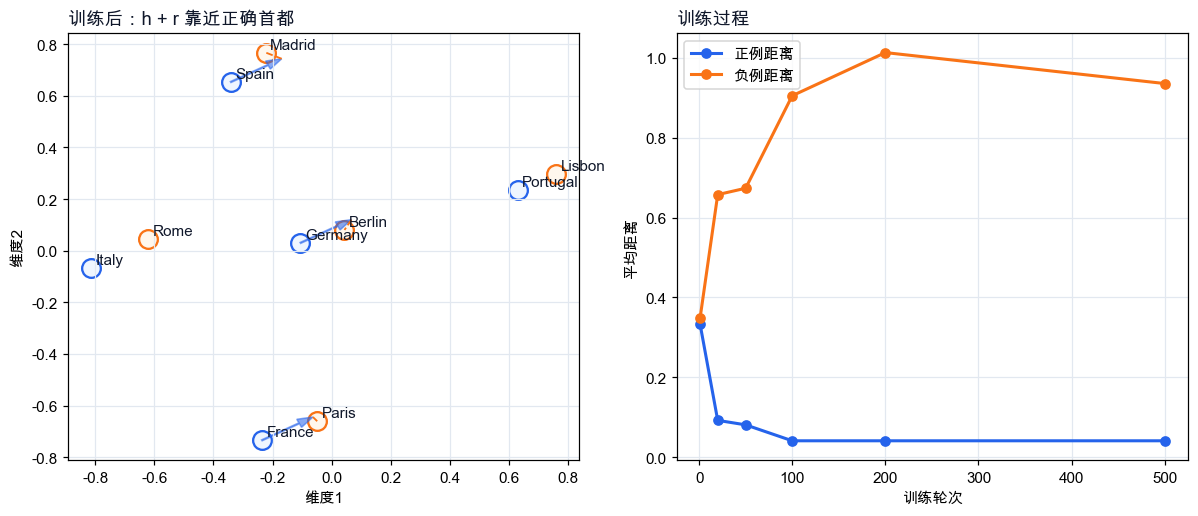

In [3]:
# 绘制训练后的实体位置、关系平移和损失变化。
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
ax = axes[0]
for name in entities:
    vec = entity_vec[entity_to_id[name]]
    is_capital = name in capitals
    ax.scatter(vec[0], vec[1], s=150, color="#fff7ed" if is_capital else "#eff6ff", edgecolor="#f97316" if is_capital else "#2563eb", linewidth=1.5)
    ax.text(vec[0] + 0.015, vec[1] + 0.015, name, color="#0f172a")

for head, _, tail in positive_triples[:3]:
    h = entity_vec[entity_to_id[head]]
    t = entity_vec[entity_to_id[tail]]
    predicted = h + relation_vec
    ax.arrow(h[0], h[1], relation_vec[0], relation_vec[1], width=0.004, head_width=0.035, color="#2563eb", alpha=0.55, length_includes_head=True)
    ax.plot([predicted[0], t[0]], [predicted[1], t[1]], color="#f97316", linewidth=1.2, linestyle="--")

ax.set_title("训练后：h + r 靠近正确首都", loc="left", fontweight="bold", color="#0f172a")
ax.set_xlabel("维度1")
ax.set_ylabel("维度2")
ax.grid(True, color="#e2e8f0", linewidth=0.8)

axes[1].plot(transe_loss_df["训练轮次"], transe_loss_df["正例平均距离"], marker="o", color="#2563eb", linewidth=2.0, label="正例距离")
axes[1].plot(transe_loss_df["训练轮次"], transe_loss_df["负例平均距离"], marker="o", color="#f97316", linewidth=2.0, label="负例距离")
axes[1].set_title("训练过程", loc="left", fontweight="bold", color="#0f172a")
axes[1].set_xlabel("训练轮次")
axes[1].set_ylabel("平均距离")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. 注意力权重

热力图的每一行代表一个正在读的词，每一列代表它可以关注的词。这里手工设置可解释的查询/键特征，目的是看清注意力如何计算；它不是训练好的 Transformer 权重。

In [4]:
# 用一组可解释的查询/键特征，让同一句话的注意力更容易读。
labels = ["这", "只", "猫", "坐", "在", "垫子"]
features = ["subject_noun", "verb", "prep", "place_noun", "det"]

K = pd.DataFrame([
    [0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 1, 0],
], index=labels, columns=features)

Q = pd.DataFrame([
    [8.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 8.0, 0.0, 0.0, 0.0],
    [6.5, 0.0, 0.0, 6.5, 0.0],
    [0.0, 0.0, 0.0, 8.0, 0.0],
    [0.0, 0.0, 0.0, 8.0, 0.0],
    [0.0, 0.0, 8.0, 0.0, 0.0],
], index=labels, columns=features)

V = np.array([
    [0.20, 0.10],
    [0.85, 0.20],
    [0.45, 0.80],
    [0.20, 0.65],
    [0.20, 0.10],
    [0.70, 0.55],
])

scores = Q.to_numpy() @ K.to_numpy().T / math.sqrt(len(features))
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights = weights / weights.sum(axis=1, keepdims=True)
attn_output = weights @ V

weight_df = pd.DataFrame(np.round(weights, 3), index=labels, columns=labels)
focus_rows = []
for i, label in enumerate(labels):
    kept = [j for j in range(len(labels)) if weights[i, j] >= 0.20]
    focus_rows.append({
        "当前词": label,
        "主要关注": ", ".join(labels[j] for j in kept),
        "权重": ", ".join(f"{weights[i, j]:.2f}" for j in kept),
    })

display(pd.DataFrame(focus_rows))
display(weight_df)
display(pd.DataFrame(np.round(attn_output, 3), index=labels, columns=["输出1", "输出2"]))

,当前词,主要关注,权重
0,这,只,0.88
1,只,猫,0.88
2,猫,"只, 垫子","0.45, 0.45"
3,坐,垫子,0.88
4,在,垫子,0.88
5,垫子,坐,0.88


,这,只,猫,坐,在,垫子
这,0.025,0.877,0.025,0.025,0.025,0.025
只,0.025,0.025,0.877,0.025,0.025,0.025
猫,0.025,0.451,0.025,0.025,0.025,0.451
坐,0.025,0.025,0.025,0.025,0.025,0.877
在,0.025,0.025,0.025,0.025,0.025,0.877
垫子,0.025,0.025,0.025,0.877,0.025,0.025


,输出1,输出2
这,0.789,0.229
只,0.448,0.741
猫,0.725,0.379
坐,0.661,0.528
在,0.661,0.528
垫子,0.234,0.613


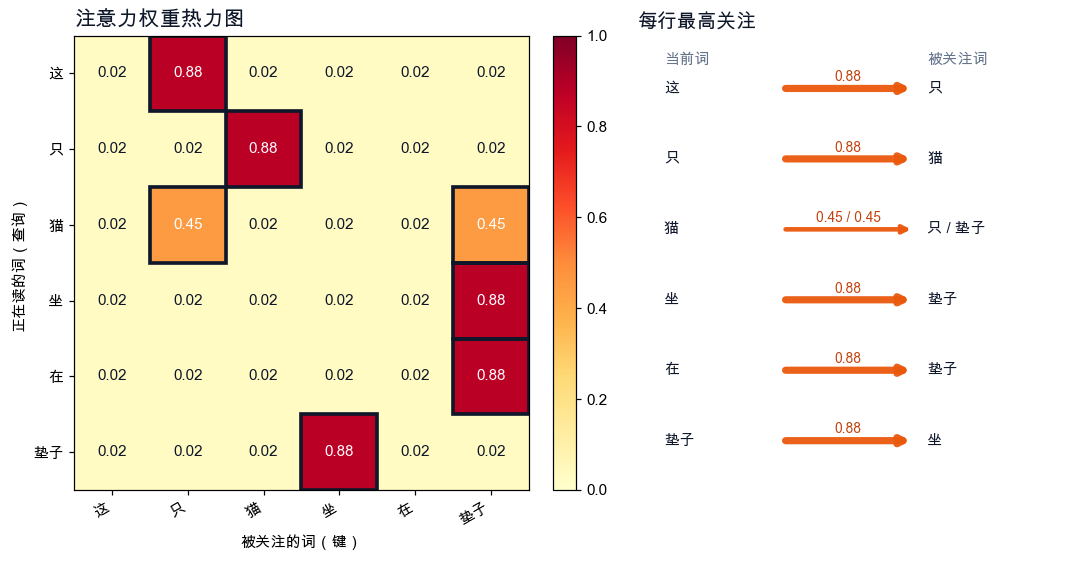

In [5]:
# 画出权重热力图，并把每一行的最高权重直接标出来。
fig, (ax, link_ax) = plt.subplots(
    1,
    2,
    figsize=(10.8, 5.2),
    gridspec_kw={"width_ratios": [1.25, 0.9]},
)
im = ax.imshow(weights, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("被关注的词（键）")
ax.set_ylabel("正在读的词（查询）")

for i in range(len(labels)):
    max_weight = weights[i].max()
    for j in range(len(labels)):
        value = weights[i, j]
        color = "#ffffff" if value > 0.45 else "#0f172a"
        weight = "bold" if value == max_weight else "normal"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontweight=weight)
        if value == max_weight:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#0f172a", linewidth=2.4))

ax.set_title("注意力权重热力图", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

link_ax.set_xlim(0, 1)
link_ax.set_ylim(-0.7, len(labels) - 0.25)
link_ax.axis("off")
link_ax.text(0.02, len(labels) - 0.15, "每行最高关注", fontsize=13, fontweight="bold", color="#0f172a")
link_ax.text(0.08, len(labels) - 0.65, "当前词", color="#64748b", fontweight="bold")
link_ax.text(0.68, len(labels) - 0.65, "被关注词", color="#64748b", fontweight="bold")

for i in range(len(labels)):
    y = len(labels) - 1 - i
    max_weight = weights[i].max()
    top_indices = [j for j in range(len(labels)) if np.isclose(weights[i, j], max_weight)]
    target_text = " / ".join(labels[j] for j in top_indices)
    value_text = " / ".join(f"{weights[i, j]:.2f}" for j in top_indices)
    link_ax.text(0.08, y, labels[i], ha="left", va="center", color="#0f172a")
    link_ax.text(0.68, y, target_text, ha="left", va="center", color="#0f172a", fontweight="bold")
    link_ax.annotate(
        "",
        xy=(0.65, y),
        xytext=(0.35, y),
        arrowprops={"arrowstyle": "->", "lw": 1.2 + 4.0 * max_weight, "color": "#ea580c", "alpha": 0.95},
    )
    link_ax.text(0.50, y + 0.16, value_text, ha="center", va="center", color="#c2410c", fontsize=9)

plt.tight_layout()
plt.show()